### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [2]:
import diffeqpy
from diffeqpy import de
from juliacall import Main as jl

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/.julia/environments/diffeqpy`


### Input data:

In [3]:
mp = 179.7      #  (submerged pipe weight) [kg/m]
N = 14   # number of modelling nodes

In [4]:
qw0 = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [5]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [6]:
Fx_0 = 1515*1000
Fy_0 = 0.8*Fx_0
LTD = 209

In [7]:
E = 207e9
G = 79.3e9
nu0 = 0.3

In [8]:
TPL = LTD/(N-1)

In [9]:
# vessel

In [10]:
mn = 39_989_000 # mass of the vessel, [kg]
L = 168 
Xg = 78 # [m]
Yg = 10
Zg = 1

In [11]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz = mn*Xg**2 + Ir
    return Iz

In [12]:
In = vessel_inertia_moment(mn, Xg, L)

In [13]:
draft = 6

In [14]:
# integration parameters
tspan = (0.,2.)

In [15]:
A_wp = 6000

In [16]:
damping_factor=1

### Main functions:

In [17]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [18]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu0) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu0) * (1.0 + m2)**2 + (20.0 + 12.0 * nu0) * m2)

In [19]:
A2 = k_shear * A
A3 = k_shear * A

In [20]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [21]:
J1 = J

In [22]:
J2 = (np.pi / 64) * (d0**4 - dI**4)
J3 = J2

In [23]:
I1=(1/2)*mp*((d0/2)**2+(dI/2)**2)*TPL

In [24]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2)*TPL
I3 = I2

In [25]:
def Πe(sφ,cφ,sθ,cθ,sψ,cψ):
    return np.array([
        [ cθ, 0, cφ * sθ], 
        [  0, 1, -sφ], 
        [-sθ, 0, cφ * cθ]
    ])    

In [26]:
def Ret_e_t(sφ,cφ,sθ,cθ,sψ,cψ):
    Cφ=np.array([[1,0,0],
                  [0,cφ,-sφ],
                  [0,sφ,cφ]])

    Cθ=np.array([[cθ,0,sθ],
                  [0,1,0],
                  [-sθ,0,cθ]])

    Cψ=np.array([[cψ,-sψ,0],
                  [sψ,cψ,0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ    

In [27]:
diag_J_t_rho = np.array([I1, I2, I3])      
J_t_rho = np.diag(diag_J_t_rho)

In [28]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT)

In [29]:
diag_CR = np.array([G*J, E*J2, E*J3]) 
CR=np.diag(diag_CR) 

In [30]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)*damping_factor

In [31]:
diag_DR = 1.5*np.array([1, 1, 1])  
DR=np.diag(diag_DR)*damping_factor

In [32]:
def I_e_rho(RET):
    return RET @ J_t_rho @ RET.T

In [33]:
def phi(x,y,z): return np.array([x,y,z])
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [34]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return 1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1))      

In [35]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [36]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [37]:
def ne(x1, y1, z1, x2, y2, z2, RET, h):
    res = RET @ CT @ RET.T @ (
        d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() 
        - RET @ np.array([1,0,0])
    )
    return res.flatten()    

In [38]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET, sφ,cφ,sθ,cθ,sψ,cψ, h):
    kappa_e = Πe(sφ,cφ,sθ,cθ,sψ,cψ) @ d_s_theta(φ1, θ1, ψ1, φ2, θ2, ψ2, h)
    return RET @ CR @ kappa_e   

In [39]:
def dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ):
   
    return np.array([
        [-sθ*dθ, 0, -sφ*dφ*sθ + cφ*cθ*dθ],
        [  0, 0, -cφ*dφ],
        [-cθ*dθ, 0, -sφ*dφ*cθ - cφ*sθ*dθ]
    ])

In [40]:
fe_g = np.array([0,0, mp*TPL*9.81])

In [41]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw0 * (DT@ A)

In [42]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = - phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

In [43]:
def Hmtrx(r):
    r = np.asarray(r, dtype=float).flatten()
    H = np.eye(6)
    H[0:3, 3:6] = S(*r).T
    return H

In [44]:
def compute_damping(M_CG, G_CG, rCG, T_x, T_y, T_n):
 
    beta_z = 0.995      
    beta_phi = 0.995    
    beta_theta = 0.995
 
   
    zeta_z = np.sqrt(1 - beta_z ** 2)
    zeta_phi = np.sqrt(1 - beta_phi ** 2)
    zeta_theta = np.sqrt(1 - beta_theta ** 2)
 
    D_CG11 = M_CG[0, 0] / T_x
    D_CG22 = M_CG[1, 1] / T_y
    D_CG66 = M_CG[5, 5] / T_n
 
   
    k_z = G_CG[2, 2] if G_CG.ndim == 2 else G_CG[2]
    k_phi = G_CG[3, 3] if G_CG.ndim == 2 else G_CG[3]
    k_theta = G_CG[4, 4] if G_CG.ndim == 2 else G_CG[4]

    D_CG33 = 2 * zeta_z * np.sqrt(np.abs(M_CG[2, 2] * k_z))
    D_CG44 = 2 * zeta_phi * np.sqrt(np.abs(M_CG[3, 3] * k_phi))
    D_CG55 = 2 * zeta_theta * np.sqrt(np.abs(M_CG[4, 4] * k_theta))
 
    D_CG = np.diag([D_CG11, D_CG22, D_CG33, D_CG44, D_CG55, D_CG66])
 
    H = Hmtrx(rCG)
    D = H.T @ D_CG @ H
 
    return D

In [45]:
def compute_added_mass_placeholder(MRB_CG, rCG, ratios=None):
    """
    Reasonable stand-in for MA when you don't yet have geometry data to run
    `compute_added_mass`, but need a plausible, positive-definite MA to
    exercise the rest of the pipeline (M, G_CG, D, eigenvalues, periods).
 
    Rather than scaling the whole MRB matrix by one constant (e.g.
    MA = 0.5*MRB), this scales each diagonal DOF of MRB_CG by a *different*,
    physically motivated ratio, since added mass/inertia does not scale
    uniformly across DOFs. Typical literature ratios for semi-submersibles/
    ships (added mass or added inertia, as a fraction of rigid-body mass or
    inertia) are used as defaults:
 
        surge : 0.10   (slender-body, low added mass fore-aft)
        sway  : 0.80   (broadside added mass is large)
        heave : 1.20   (column-stabilized units: often exceeds rigid mass)
        roll  : 0.30   (added inertia, moderate)
        pitch : 0.90   (added inertia, large - long waterline)
        yaw   : 0.90   (added inertia, large)
 
    These are ROUGH DEFAULTS ONLY -- real added mass depends on hull/column/
    pontoon shape, submergence, and frequency, and should eventually be
    replaced by `compute_added_mass` once geometry data is available.
 
    Parameters
    ----------
    MRB_CG : (6, 6) ndarray
        Rigid-body mass matrix at CG (block-diagonal: m*I3, diag(Ix,Iy,Iz)).
    rCG : (3,) array_like
        Center of gravity with respect to CO (for the CG -> CO transform).
    ratios : (6,) array_like, optional
        Override the six default ratios above, in DOF order
        [surge, sway, heave, roll, pitch, yaw].
 
    Returns
    -------
    MA : (6, 6) ndarray
        Added mass matrix with respect to CO (diagonal at CG, transformed
        to CO -- no cross-coupling terms, unlike a geometry-derived MA).
    """
 
    if ratios is None:
        ratios = [0.10, 0.80, 1.20, 0.30, 0.90, 0.90]
 
    diag_CG = np.diag(MRB_CG)
    MA_CG = np.diag(diag_CG * np.asarray(ratios, dtype=float))
 
    # Transform from CG to CO -- same pattern used for MRB_CG -> MRB
    # elsewhere in this script: X_CO = Hmtrx(rCG).T @ X_CG @ Hmtrx(rCG)
    MA = Hmtrx(rCG).T @ MA_CG @ Hmtrx(rCG)
 
    return MA

In [46]:
def coriolis_matrix(M, nu):
    U = np.linalg.norm(nu)
    L = np.zeros((6, 6))
    L[1, 5] = 1.0  
    L[2, 4] = -1.0 
    C = M @ (U * L)
    return C

In [47]:
e1 = np.array([1.0, 0.0, 0.0])
e2 = np.array([0.0, 1.0, 0.0])
e3 = np.array([0.0, 0.0, 1.0])

In [48]:
class VesselRestoringParams:
    """
    Physical/geometric parameters needed for the restoring
    force/moment model, eqs. (57)-(63).
    """
    def __init__(self, A_wp, rho_w, g, z_eq, m_V, GM_L, GM_T):
        self.A_wp = A_wp      # water plane area [m^2]
        self.rho_w = rho_w    # water density [kg/m^3]
        self.g = g            # gravitational acceleration [m/s^2]
        self.z_eq = z_eq      # heave equilibrium position [m]
        self.m_V = m_V        # vessel mass [kg]
        self.GM_L = GM_L      # longitudinal metacentric height [m]
        self.GM_T = GM_T      # transversal metacentric height [m]

In [49]:
def heave_restoring_force(u_L, params: VesselRestoringParams):
    """
    g^e_l = -A_wp * rho_w * g * (u^T(L,t) e3 - z_eq) * e3

    Parameters
    ----------
    u_L : (3,) array
        Position of the pipe end attached to the vessel, u(L, t),
        expressed in the earth-fixed frame e.
    """
    heave = u_L @ e3
    g_e_l = -params.A_wp * params.rho_w * params.g * (heave - params.z_eq) * e3
    return g_e_l

In [50]:
def roll_pitch_sines(R_e_b):
    """
    sin(theta) and sin(phi) without explicit Euler angles, eqs. (59)-(60):
        sin(theta) = (R^e_b e1)^T e3
        sin(phi)  ~= (R^e_b e2)^T e3     (small-pitch approximation, cos(theta)=1)
    """
    sin_theta = (R_e_b @ e1) @ e3
    sin_phi = (R_e_b @ e2) @ e3
    return sin_phi, sin_theta

In [51]:
def moment_arm_body(R_e_b, params: VesselRestoringParams):
    """
    r~^b_r, eq. (61):
        r~^b_r = [ GM_L * (R^e_b e1)^T e3 ,
                   GM_T * (R^e_b e2)^T e3 ,
                   0 ]^T
    """
    sin_phi, sin_theta = roll_pitch_sines(R_e_b)
    r_tilde_b_r = np.array([
        params.GM_L * sin_theta,
        params.GM_T * sin_phi,
        0.0
    ])
    return r_tilde_b_r

In [52]:
def restoring_moment(R_e_b, params: VesselRestoringParams):
    """
    g^e_r = r~^e_r x f^e_r = (R^e_b r~^b_r) x (m_V g e3)
    """
    r_tilde_b_r = moment_arm_body(R_e_b, params)
    r_tilde_e_r = R_e_b @ r_tilde_b_r
    f_e_r = params.m_V * params.g * e3
    g_e_r = np.cross(r_tilde_e_r, f_e_r)
    return g_e_r

In [53]:
def restoring_vector_body(u_L, R_e_b, params: VesselRestoringParams):
    """
    g^b(u(L,t), R^e_b(t)) =
        [ (R^e_b)^T g^e_t ]
        [ (R^e_b)^T g^e_r ]

    where g^e_t = g^e_l (only heave translational restoring, eq. 57)
    and   g^e_r is the restoring moment, eq. (62).

    Returns
    -------
    g_b : (6,) ndarray
        [Fx, Fy, Fz, Mx, My, Mz] restoring generalized force in body frame.
    """
    g_e_t = heave_restoring_force(u_L, params)      # translational restoring, e-frame
    g_e_r = restoring_moment(R_e_b, params)          # rotational restoring, e-frame

    g_b_t = R_e_b.T @ g_e_t
    g_b_r = R_e_b.T @ g_e_r

    g_b = np.concatenate([g_b_t, g_b_r])
    return g_b

In [54]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        
        self.r_g = np.array([Xg, Yg, Zg])
        self.r_b = np.array([0, 0, -draft/2])
        
        self.W = mn*9.81
        self.BO = self.W
        
        self.MRB = np.block([[mn*np.identity(3), np.zeros((3,3))], 
                             [np.zeros((3,3)), In*np.identity(3)]])
        
        self.MA = compute_added_mass_placeholder(self.MRB, self.r_g)
        
        self.M = self.MRB + self.MA

        self.CRB = coriolis_matrix
        
        self.CA = coriolis_matrix
        self.prev_acc=np.array([0,0,0,0,0,0])

### Static solution

In [55]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [56]:
mi = [mp for i in range(N)]

In [57]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [58]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [59]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [60]:
delta_x=horizontal_length/(N-1)

In [61]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [62]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

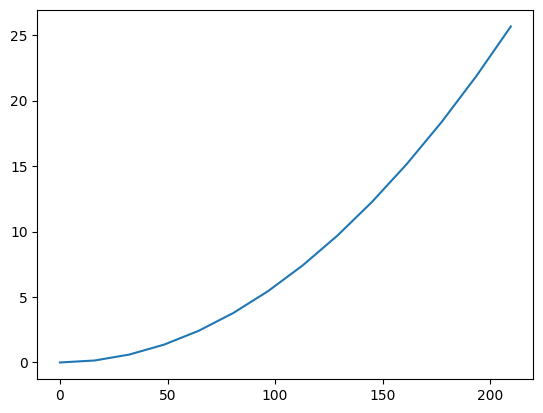

In [63]:
plt.plot(x0, z0)
plt.show()

In [64]:
q0=np.zeros(12*N)

In [65]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [66]:
h = delta_x

In [67]:
def fun1(x_int, sφ,cφ,sθ,cθ,sψ,cψ, RET):
    
    def fun1_(x_int, sφ,cφ,sθ,cθ,sψ,cψ, RET):
        A=mp*TPL*1/2*(1-x_int)*1/2*(1+x_int)*np.identity(3)
        B=np.zeros((3,3))
        
        D=1/2*(1-x_int)*1/2*(1+x_int)*I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)
            
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(xi, sφ,cφ,sθ,cθ,sψ,cψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2_1(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
    
    def fun2_1_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2,RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, x2, y2, z2, RET, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h))), axis=None)
    
    res = np.array([fun2_1_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun2_2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
    
    def fun2_2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1-x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, x2, y2, z2, RET, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h))), axis=None)
    
    res = np.array([fun2_2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET, sφ,cφ,sθ,cθ,sψ,cψ, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun3_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET):
    
    def fun3_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET):
        A=np.zeros(3)
          
        B=1/2*(1+x_int)*I_e_rho(RET)@dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)  

    
def fun3_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun3_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3)
          
        B=1/2*(1-x_int)*I_e_rho(RET)@dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun4_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun4_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3)
            
        B=1/2*(1+x_int)*S(*(Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun4_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun4_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3) 
       
        B=1/2*(1-x_int)*S(*(Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun5_1(x_int, li):
    
    def fun5_1_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_1_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun5_2(x_int, li):
    
    def fun5_2_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1-x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_2_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun6_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET):
    
    def fun6_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
        A=1/2*(1+x_int)* RET@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(sφ,cφ,sθ,cθ,sψ,cψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)  
    
    res = np.array([fun6_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun6_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
    
    def fun6_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
        A=1/2*(1-x_int)* RET@f_t_d(dx,dy,dz)
        B=1/2*(1-x_int)* DR@ Πe(sφ,cφ,sθ,cθ,sψ,cψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun7_1(x_int,x,y,z):
   
    def fun7_1_(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_1_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun7_2(x_int,x,y,z):
   
    def fun7_2_(x_int,x,y,z):
        A=1/2*(1-x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_2_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

In [68]:
def body_frame_nu(u_dot_xyz, sφ,cφ,sθ,cθ,sψ,cψ,  dphi, dtheta, dpsi, RET):
    """Eq. (64): rotate spatial velocity + convert Euler rates -> body-frame nu."""
    Re_b = RET
    w_e  = Πe(sφ,cφ,sθ,cθ,sψ,cψ) @ np.array([dphi, dtheta, dpsi])   # Eq. (100)
    nu_lin = Re_b.T @ np.asarray(u_dot_xyz)
    nu_ang = Re_b.T @ w_e
    return np.concatenate([nu_lin, nu_ang])

In [69]:
def quat_normalize(q):
    q = np.asarray(q, dtype=float)
    n = np.linalg.norm(q)
    if n < 1e-14:
        return np.array([1.0, 0.0, 0.0, 0.0])
    return q / n

def quat_to_R(q):
    qw, qx, qy, qz = quat_normalize(q)
    return np.array([
        [1-2*(qy*qy+qz*qz), 2*(qx*qy-qz*qw), 2*(qx*qz+qy*qw)],
        [2*(qx*qy+qz*qw), 1-2*(qx*qx+qz*qz), 2*(qy*qz-qx*qw)],
        [2*(qx*qz-qy*qw), 2*(qy*qz+qx*qw), 1-2*(qx*qx+qy*qy)]
    ])

def quat_mul(q, p):
    w,x,y,z = q
    W,X,Y,Z = p
    return np.array([
        w*W-x*X-y*Y-z*Z,
        w*X+x*W+y*Z-z*Y,
        w*Y-x*Z+y*W+z*X,
        w*Z+x*Y-y*X+z*W
    ])

def quat_from_R(R):
    # Robust conversion of a proper rotation matrix to [qw,qx,qy,qz].
    tr = np.trace(R)
    if tr > 0.0:
        s = 2.0*np.sqrt(tr + 1.0)
        qw = 0.25*s
        qx = (R[2,1]-R[1,2])/s
        qy = (R[0,2]-R[2,0])/s
        qz = (R[1,0]-R[0,1])/s
    else:
        i = np.argmax(np.diag(R))
        if i == 0:
            s = 2.0*np.sqrt(max(1.0 + R[0,0]-R[1,1]-R[2,2], 1e-15))
            qw = (R[2,1]-R[1,2])/s
            qx = 0.25*s
            qy = (R[0,1]+R[1,0])/s
            qz = (R[0,2]+R[2,0])/s
        elif i == 1:
            s = 2.0*np.sqrt(max(1.0 + R[1,1]-R[0,0]-R[2,2], 1e-15))
            qw = (R[0,2]-R[2,0])/s
            qx = (R[0,1]+R[1,0])/s
            qy = 0.25*s
            qz = (R[1,2]+R[2,1])/s
        else:
            s = 2.0*np.sqrt(max(1.0 + R[2,2]-R[0,0]-R[1,1], 1e-15))
            qw = (R[1,0]-R[0,1])/s
            qx = (R[0,2]+R[2,0])/s
            qy = (R[1,2]+R[2,1])/s
            qz = 0.25*s
    return quat_normalize(np.array([qw,qx,qy,qz]))

def quat_dot_spatial(q, omega_e):
    # Rdot = S(omega_e) R  ->  qdot = 1/2 [0,omega_e] ⊗ q
    return 0.5 * quat_mul(np.array([0.0, *omega_e]), q)

def R_to_euler(R):
    # Inverse of R = C_theta C_phi C_psi used by Ret_e_t().
    # These angles are only auxiliary variables for the existing pipe equations.
    r20 = np.clip(R[2,0], -1.0, 1.0)
    theta = -np.arcsin(r20)
    ctheta = np.cos(theta)
    if abs(ctheta) > 1e-8:
        phi = np.arctan2(R[2,1], R[2,2])
        psi = np.arctan2(R[1,0], R[0,0])
    else:
        # Euler angles are undefined at gimbal lock; quaternion itself remains valid.
        phi = 0.0
        psi = np.arctan2(-R[0,1], R[1,1])
    return phi, theta, psi

In [70]:
def node_dof_slice(node):
    # node is a physical node index 1..N-1
    k = (node-1)*6
    return slice(k,k+6)

def euler_from_qnode(q):
    R = quat_to_R(q)
    return R_to_euler(R)

In [71]:
def rotation_at_node(Q_or_state,j):
    """Return the node-j quaternion from either a full dynamic state or Q=[x,y,z,phi,theta,psi]."""
    a = np.asarray(Q_or_state)
    if a.size >= 22*N:
        # Full state: quaternion block starts at 18*N.
        kq = 18*N
        qj = np.array([a[kq+j], a[kq+N+j], a[kq+2*N+j], a[kq+3*N+j]])
        return quat_normalize(qj)
    if a.size == 6*N:
        # Reduced configuration Q has no quaternion block; reconstruct it from Euler angles.
        phi_j, theta_j, psi_j = a[3*N+j], a[4*N+j], a[5*N+j]
        Rj = Ret_e_t(np.sin(phi_j), np.cos(phi_j),
                      np.sin(theta_j), np.cos(theta_j),
                      np.sin(psi_j), np.cos(psi_j))
        return quat_from_R(Rj)
    raise ValueError(f"rotation_at_node: expected full state ({22*N}+) or Q ({6*N}) entries, got {a.size}")

def pi_at_angles(sφ, cφ, sθ, cθ, sψ, cψ):
    return Πe(sφ, cφ, sθ, cθ, sψ, cψ)

In [72]:
NA = N-1
DOF_PER_NODE = 6
NDOF = DOF_PER_NODE*NA

In [73]:
def assemble_pipe_mass(Q, TM, sφ, cφ, sθ, cθ, sψ, cψ):
    """
    Assembles the global consistent pipe inertia matrix using 2-point Gaussian quadrature.
    """
    M = np.zeros((NDOF, NDOF))
    
    xi = np.array([-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)])
    w = np.array([1.0, 1.0])
    
    Na = (1.0 - xi) / 2.0
    Nb = (1.0 + xi) / 2.0

    for e in range(N-1):
        a, b = e, e+1
        
  
        qa = rotation_at_node(Q, a)
        qb = rotation_at_node(Q, b)
        
        Me = np.zeros((12, 12))
        
        for i in range(2):
            q_int = qa * Na[i] + qb * Nb[i]
            q_int = quat_normalize(q_int)
            
            R_int = quat_to_R(q_int)
            phi_int, theta_int, psi_int = R_to_euler(R_int)
            P_int = pi_at_angles(sφ[e],cφ[e],sθ[e],cθ[e], sψ[e],cψ[e])
            
            Mbar = np.zeros((6, 6))
            Mbar[:3, :3] = mp * TPL*np.eye(3)
            Mbar[3:, 3:] = P_int.T @ I_e_rho(R_int) @ P_int  
            
            N_mat = np.zeros((6, 12))
            N_mat[:6, :6] = Na[i] * np.eye(6)
            N_mat[:6, 6:] = Nb[i] * np.eye(6)
            
            Me += (h / 2.0) * w[i] * (N_mat.T @ Mbar @ N_mat)
            
        nodes = [a, b]
        for ia, na in enumerate(nodes):
            if na == 0: continue
            I = node_dof_slice(na)
            for ib, nb in enumerate(nodes):
                if nb == 0: continue
                J = node_dof_slice(nb)
                M[I, J] += Me[ia*6:(ia+1)*6, ib*6:(ib+1)*6]

    j = N-1
    qj = rotation_at_node(Q, j)
    R = quat_to_R(qj)
    phi_j, theta_j, psi_j = R_to_euler(R)
    P = pi_at_angles(sφ[j],cφ[j],sθ[j],cθ[j], sψ[j],cψ[j])
    
    Jgen = np.block([
        [R.T, np.zeros((3, 3))],
        [np.zeros((3, 3)), R.T @ P]
    ])
    
    M[node_dof_slice(j), node_dof_slice(j)] += Jgen.T @ TM @ Jgen
    
    return M

In [74]:
def static_solution(Q,T): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    sφ,cφ,sθ,cθ,sψ,cψ=Q[12*N:13*N],Q[13*N:14*N],Q[14*N:15*N],Q[15*N:16*N],Q[16*N:17*N],Q[17*N:18*N]
    
    kq = 18*N
    qw,qx,qy,qz = Q[kq+0*N:kq+1*N], Q[kq+1*N:kq+2*N], Q[kq+2*N:kq+3*N], Q[kq+3*N:kq+4*N]
    
   
    
   
    dsφ,dcφ,dsθ,dcθ,dsψ,dcψ=np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N)
    dqw=np.zeros(N); dqx=np.zeros(N); dqy=np.zeros(N); dqz=np.zeros(N)
    
    M=assemble_pipe_mass(Q,np.zeros((6,6)), sφ,cφ,sθ,cθ,sψ,cψ)
    R=np.zeros(NDOF)
    
    for j in range(1, N):
        
        qj = quat_normalize(np.array([qw[j],qx[j],qy[j],qz[j]]))
        RET = quat_to_R(qj)
        
        omega_e = Πe(
            sφ[j],cφ[j],
            sθ[j],cθ[j],
            sψ[j],cψ[j]
        ) @ np.array([
            dφ[j],
            dθ[j],
            dψ[j]
        ])

       
        dsφ[j],dcφ[j],dsθ[j],dcθ[j],dsψ[j],dcψ[j]=  dφ[j]*cφ[j],-dφ[j]*sφ[j],   dθ[j]*cθ[j],-dθ[j]*sθ[j],   dψ[j]*cψ[j], -dψ[j]*sψ[j]

        qdot = quat_dot_spatial(qj, omega_e)
        dqw[j],dqx[j],dqy[j],dqz[j] = qdot

        P = pi_at_angles(sφ[j],cφ[j],sθ[j],cθ[j], sψ[j],cψ[j])
        Jgen = np.block([
                [RET.T, np.zeros((3, 3))],
                [np.zeros((3, 3)), RET.T @ P]
            ]) 
        
        if j == N-1:
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), RET, 
                                      VesselRestoringParams(
                                                            A_wp = A_wp,     # m^2, water plane area
                                                            rho_w = qw0,    # kg/m^3
                                                            g = 9.81,       # m/s^2
                                                            z_eq = z0[-1],  # equilibrium heave [m]
                                                            m_V = mn,       # kg, vessel mass
                                                            GM_L = L,       # m, longitudinal metacentric height
                                                            GM_T = 2*Yg,        # m, transversal metacentric height
                                                        ))
            
            r = integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun3_1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
            r += integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
            r += integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
            r += integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
            r += integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
            f8 = - g_eta
            R[node_dof_slice(j)] = -r + Jgen.T@(f8+np.array([Fx_0,0,0,0,0,0]))
        else:
            r =(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0])
            r+=(integrate.fixed_quad(lambda x_int: fun3_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            r+=(integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            r+=(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            r+=(integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            r+=(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            R[node_dof_slice(j)] = -r

      
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
   
   
    X = np.linalg.solve(M, R).reshape(N-1, 6)

    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  

    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0
      
    ans=np.concatenate([
        dx, ddx,
        dy, ddy,
        dz, ddz,
    
        dφ, ddφ,
        dθ, ddθ,
        dψ, ddψ,
    
        dsφ, dcφ,
        dsθ, dcθ,
        dsψ, dcψ,
    
        dqw,dqx,dqy,dqz
    ], axis=0)
  
    return ans

In [75]:
T_1 = MyTime()

In [76]:
φ_init = q0[6*N : 7*N]
θ_init = q0[8*N : 9*N]
ψ_init = q0[10*N : 11*N]

Qquat = np.zeros((N, 4))
for j in range(N):
    phi_j   = φ_init[j]
    theta_j = θ_init[j]
    psi_j   = ψ_init[j]
    
    sφ, cφ = np.sin(phi_j), np.cos(phi_j)
    sθ, cθ = np.sin(theta_j), np.cos(theta_j)
    sψ, cψ = np.sin(psi_j), np.cos(psi_j)
    
    Rj = Ret_e_t(sφ, cφ, sθ, cθ, sψ, cψ)
    Qquat[j] = quat_from_R(Rj)

cs0 = np.concatenate((
    np.sin(φ_init), np.cos(φ_init),
    np.sin(θ_init), np.cos(θ_init),
    np.sin(ψ_init), np.cos(ψ_init)
))

Q0_final = np.concatenate((q0, cs0, Qquat[:,0], Qquat[:,1], Qquat[:,2], Qquat[:,3]))
q0 = np.concatenate((q0,cs0,Qquat[:,0],Qquat[:,1],Qquat[:,2],Qquat[:,3]))

In [77]:
root_ = root(static_solution, q0, 
             # method='lm', 
             args=(T_1,))

In [78]:
root_

 message: The iteration is not making good progress, as measured by the 
            improvement from the last ten iterations.
 success: False
  status: 5
     fun: [ 3.058e-11 -2.342e-10 ...  4.208e-15  1.287e-17]
       x: [-1.211e+01  3.921e+00 ... -8.733e-02 -2.515e-08]
  method: hybr
    nfev: 1249
    fjac: [[-6.208e-18  1.251e-17 ...  1.207e-20  2.061e-20]
           [-3.209e-18  7.473e-19 ...  7.210e-22  1.232e-21]
           ...
           [ 1.874e-55 -9.380e-55 ...  3.819e-31  1.650e-28]
           [ 8.739e-57 -1.982e-56 ... -2.511e-32  4.156e-30]]
       r: [-9.109e+05 -6.905e+06 ... -6.228e-40 -1.551e-41]
     qtf: [ 1.616e+06  9.655e+04 ...  2.905e-37  2.541e-38]

In [79]:
x0_, y0_, z0_ = root_.x[:N],root_.x[2*N:3*N], root_.x[4*N:5*N]

In [80]:
x0_-=x0_[0]
y0_-=y0_[0]

In [81]:
q0 = root_.x                                         # start from static solution

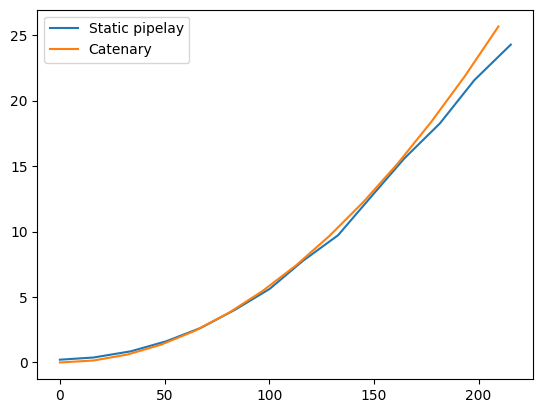

In [82]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

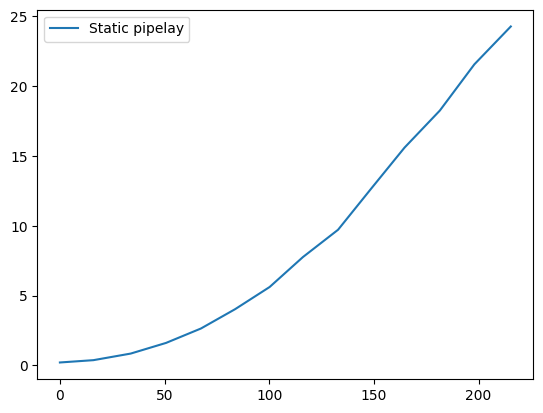

In [83]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.legend()
plt.show()

### Dynamic Simulation

In [84]:
def dynamic_func(du, Q, T, t):

    x,  y,  z  = Q[0*N : 1*N], Q[2*N : 3*N], Q[4*N : 5*N]
    dx, dy, dz = Q[1*N : 2*N], Q[3*N : 4*N], Q[5*N : 6*N]
    φ,  θ,  ψ  = Q[6*N : 7*N], Q[8*N : 9*N], Q[10*N:11*N]
    dφ, dθ, dψ = Q[7*N : 8*N], Q[9*N : 10*N], Q[11*N:12*N]

    
    sφ, cφ = np.sin(φ), np.cos(φ)
    sθ, cθ = np.sin(θ), np.cos(θ)
    sψ, cψ = np.sin(ψ), np.cos(ψ)

    kq = 18 * N
    qw, qx, qy, qz = Q[kq+0*N : kq+1*N], Q[kq+1*N : kq+2*N], Q[kq+2*N : kq+3*N], Q[kq+3*N : kq+4*N]

    dsφ = np.zeros(N); dcφ = np.zeros(N)
    dsθ = np.zeros(N); dcθ = np.zeros(N)
    dsψ = np.zeros(N); dcψ = np.zeros(N)
    dqw = np.zeros(N); dqx = np.zeros(N); dqy = np.zeros(N); dqz = np.zeros(N)

    M = assemble_pipe_mass(Q, T.M, sφ, cφ, sθ, cθ, sψ, cψ)
    R = np.zeros(NDOF)

    K_stab = 10.0 

    for j in range(1, N):
        q_raw = np.array([qw[j], qx[j], qy[j], qz[j]])
        q_norm_sq = np.sum(q_raw**2)
        q_norm = np.sqrt(q_norm_sq)
        
        qj = q_raw / (q_norm if q_norm > 1e-12 else 1.0)
        RET = quat_to_R(qj)
        
        omega_e = Πe(sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j]) @ np.array([dφ[j], dθ[j], dψ[j]])

        dsφ[j], dcφ[j] =  dφ[j] * cφ[j], -dφ[j] * sφ[j]
        dsθ[j], dcθ[j] =  dθ[j] * cθ[j], -dθ[j] * sθ[j]
        dsψ[j], dcψ[j] =  dψ[j] * cψ[j], -dψ[j] * sψ[j]

        qdot = quat_dot_spatial(qj, omega_e)
        q_corrected_dot = qdot - K_stab * (q_norm_sq - 1.0) * qj
        dqw[j], dqx[j], dqy[j], dqz[j] = q_corrected_dot
        
        P = pi_at_angles(sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j])
        Jgen = np.block([
            [RET.T, np.zeros((3, 3))],
            [np.zeros((3, 3)), RET.T @ P]
        ]) 
        
        if j == N - 1:
            nu = body_frame_nu(np.array([dx[j], dy[j], dz[j]]), sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET)
            C_nu = T.CRB(T.MRB, nu) + T.CA(T.MA, nu)
            g_eta = restoring_vector_body(phi(x[j], y[j], z[j]), RET, VesselRestoringParams(
                A_wp=A_wp, rho_w=qw0, g=9.81, z_eq=z0_[-1], m_V=mn, GM_L=L, GM_T=2*Yg
            ))
            D_nu = compute_damping(T.MRB, g_eta, T.r_g, 20, 100, 50)
            
            r = integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], RET, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], h), -1.0, 1.0, n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun3_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun4_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun6_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dx[j], dy[j], dz[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
            r += integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j], y[j], z[j]), -1.0, 1.0, n=1)[0]
            f8 = -((C_nu + D_nu) @ nu + g_eta)
            R[node_dof_slice(j)] = - r + Jgen.T @ (f8 + np.array([Fx_0, 0, 0, 0, 0, 0])) 
        else:
            r = (integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], RET, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], h), -1.0, 1.0, n=1)[0]
                 + integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j], y[j], z[j], φ[j], θ[j], ψ[j], x[j+1], y[j+1], z[j+1], φ[j+1], θ[j+1], ψ[j+1], RET, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], h), -1.0, 1.0, n=1)[0])
            r += (integrate.fixed_quad(lambda x_int: fun3_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
                  + integrate.fixed_quad(lambda x_int: fun3_2(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0])
            r += (integrate.fixed_quad(lambda x_int: fun4_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
                  + integrate.fixed_quad(lambda x_int: fun4_2(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0])
            r += (integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=1)[0]
                  + integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=1)[0])
            r += (integrate.fixed_quad(lambda x_int: fun6_1(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dx[j], dy[j], dz[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0]
                  + integrate.fixed_quad(lambda x_int: fun6_2(x_int, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], dx[j], dy[j], dz[j], dφ[j], dθ[j], dψ[j], RET), -1.0, 1.0, n=1)[0])
            r += (integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j], y[j], z[j]), -1.0, 1.0, n=1)[0]
                  + integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j], y[j], z[j]), -1.0, 1.0, n=1)[0])
            R[node_dof_slice(j)] = - r
        
        if t > 0.01 and j > 0:
            ax = RET.T @ ne(x[j-1], y[j-1], z[j-1], x[j], y[j], z[j], RET, h).T
            T.top_tension = max(T.top_tension, ax[0])            
                                     
            ben0 = RET.T @ me(φ[j-1], θ[j-1], ψ[j-1], φ[j], θ[j], ψ[j], RET, sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j], h)
            ben = np.max(ben0[1:])
            I = 3.14 * (d0**4 - dI**4) / 64
            strain = np.max(ben) * d0 / (2 * E * I)    
            T.sagbend_strain = max(T.sagbend_strain, strain)    

    M_64 = M.astype(np.float64)
    R_64 = R.astype(np.float64)


    max_mass = np.max(np.abs(M_64))
    np.fill_diagonal(M_64, M_64.diagonal() + max_mass * 1e-4)
    lu, piv = scipy.linalg.lu_factor(M_64)

    X_raw = scipy.linalg.lu_solve((lu, piv), R_64)

    residual = M_64 @ X_raw - R_64
    dX = scipy.linalg.lu_solve((lu, piv), residual)
    X_corrected = X_raw - dX

    X = X_corrected.reshape(N - 1, 6)

    ddx = np.zeros(N)
    ddy = np.zeros(N)
    ddz = np.zeros(N)
    ddφ = np.zeros(N)
    ddθ = np.zeros(N)
    ddψ = np.zeros(N)

    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  
    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0
 
    ans = np.concatenate([
        dx, ddx,
        dy, ddy,
        dz, ddz,
    
        dφ, ddφ,
        dθ, ddθ,
        dψ, ddψ,
    
        dsφ, dcφ,
        dsθ, dcθ,
        dsψ, dcψ,
    
        dqw, dqx, dqy, dqz
    ], axis=0)
  
    if t > T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock, flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter += 1 


    if np.any(np.abs(ans) > 1e10) or np.any(np.isnan(ans)):
        print(f"\n!!! CRITICAL SYSTEM EXPLOSION AT t = {t} !!!")
        
        bad_idx = np.where((np.abs(ans) > 1e10) | (np.isnan(ans)))[0]
        for idx in bad_idx:
            print(f"Index Q[{idx}] returned an invalid value: {ans[idx]}")
               
        print("Right-hand side vector R (first 20 elements):", R[:20])
        print("Condition number of mass matrix M:", np.linalg.cond(M_64))
        
        raise ValueError("Simulation aborted due to Inf/NaN generation.")

        
    du[:] = ans
    return None


In [85]:
T_2=MyTime()

In [86]:
def find_static_equilibrium(q0_guess, T, N, NDOF):
  
    x_init = q0_guess[0*N : 1*N]
    y_init = q0_guess[2*N : 3*N]
    z_init = q0_guess[4*N : 5*N]
    φ_init = q0_guess[6*N : 7*N]
    θ_init = q0_guess[8*N : 9*N]
    ψ_init = q0_guess[10*N : 11*N]
    
    geom_guess = np.concatenate([x_init, y_init, z_init, φ_init, θ_init, ψ_init])
    
    def static_residuals(geom_vector):
        x = geom_vector[0*N : 1*N]
        y = geom_vector[1*N : 2*N]
        z = geom_vector[2*N : 3*N]
        φ = geom_vector[3*N : 4*N]
        θ = geom_vector[4*N : 5*N]
        ψ = geom_vector[5*N : 6*N]
        
        v_zeros = np.zeros(N)
        
        sφ, cφ = np.sin(φ), np.cos(φ)
        sθ, cθ = np.sin(θ), np.cos(θ)
        sψ, cψ = np.sin(ψ), np.cos(ψ)
        
        Qquat = np.zeros((N, 4))
        for j in range(N):
            Rj = Ret_e_t(sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j])
            Qquat[j] = quat_from_R(Rj)
            
        cs0 = np.concatenate((sφ, cφ, sθ, cθ, sψ, cψ))
        
        Q_test = np.concatenate([
            x, v_zeros,        # 0*N : 2*N
            y, v_zeros,        # 2*N : 4*N
            z, v_zeros,        # 4*N : 6*N
            φ, v_zeros,        # 6*N : 8*N
            θ, v_zeros,        # 8*N : 10*N
            ψ, v_zeros,        # 10*N : 12*N
            cs0,               # 12*N : 18*N
            Qquat[:,0], Qquat[:,1], Qquat[:,2], Qquat[:,3] # 18*N : 22*N
        ])
        
        du_output = np.zeros_like(Q_test)
        dynamic_func(du_output, Q_test, T, 0.0)
        
        ddx = du_output[1*N : 2*N]
        ddy = du_output[3*N : 4*N]
        ddz = du_output[5*N : 6*N]
        ddφ = du_output[7*N : 8*N]
        ddθ = du_output[9*N : 10*N]
        ddψ = du_output[11*N : 12*N]
        

        residuals = np.concatenate([
            ddx[1:], ddy[1:], ddz[1:],
            ddφ[1:], ddθ[1:], ddψ[1:]
        ])
        
       
        fix_residuals = np.array([x[0]-x_init[0], y[0]-y_init[0], z[0]-z_init[0], 
                                  φ[0]-φ_init[0], θ[0]-θ_init[0], ψ[0]-ψ_init[0]])
        
        return np.concatenate([fix_residuals, residuals])

    print("Launching static equilibrium calculation...")
    result = root(static_residuals, geom_guess, method='hybr', tol=1e-5)
    
    if not result.success:
        print("WARNING: Static solution failed to converge! Message:", result.message)
    else:
        print("Static equilibrium successfully found!")

        
    geom_opt = result.x
    x_opt = geom_opt[0*N : 1*N]
    y_opt = geom_opt[1*N : 2*N]
    z_opt = geom_opt[2*N : 3*N]
    φ_opt = geom_opt[3*N : 4*N]
    θ_opt = geom_opt[4*N : 5*N]
    ψ_opt = geom_opt[5*N : 6*N]
    
    v_zeros = np.zeros(N)
    sφ, cφ = np.sin(φ_opt), np.cos(φ_opt)
    sθ, cθ = np.sin(θ_opt), np.cos(θ_opt)
    sψ, cψ = np.sin(ψ_opt), np.cos(ψ_opt)
    
    Qquat = np.zeros((N, 4))
    for j in range(N):
        Rj = Ret_e_t(sφ[j], cφ[j], sθ[j], cθ[j], sψ[j], cψ[j])
        Qquat[j] = quat_from_R(Rj)
        
    cs0 = np.concatenate((sφ, cφ, sθ, cθ, sψ, cψ))
    
    Q0_perfect = np.concatenate([
        x_opt, v_zeros, y_opt, v_zeros, z_opt, v_zeros,
        φ_opt, v_zeros, θ_opt, v_zeros, ψ_opt, v_zeros,
        cs0, Qquat[:,0], Qquat[:,1], Qquat[:,2], Qquat[:,3]
    ])
    
    return Q0_perfect

In [87]:
Q0_balanced = find_static_equilibrium(q0, T_2, N, NDOF)

Launching static equilibrium calculation...
  improvement from the last ten iterations.


In [88]:
x0_1, y0_1, z0_1 = Q0_balanced[:N], Q0_balanced[2*N:3*N], Q0_balanced[4*N:5*N]

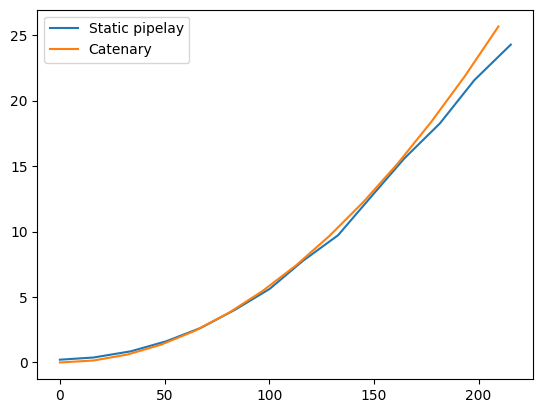

In [89]:
plt.plot(x0_1, z0_1, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

In [90]:
T_3=MyTime()

In [91]:
startTime1 = datetime.now()
jl.seval("""
using Pkg
Pkg.add("OrdinaryDiffEqSDIRK")
using DifferentialEquations
using OrdinaryDiffEqSDIRK
""")

de = jl.seval("DifferentialEquations")
sdirk = jl.seval("OrdinaryDiffEqSDIRK")

# Problem
prob = de.ODEProblem(
    dynamic_func,
    Q0_balanced,
    tspan,
    jl.Py(T_3)
)

sol = de.solve(
    prob,
    de.Rosenbrock23(autodiff=de.AutoFiniteDiff()),
    reltol=1e-6,
    abstol=1e-6 
)
print(datetime.now() - startTime1)

   Resolving package versions...
  No Changes to `~/.julia/environments/diffeqpy/Project.toml`
  No Changes to `~/.julia/environments/diffeqpy/Manifest.toml`


Physical time:  1.859166108863025e-05  Iteration wall-clock time:  0:00:11.921751
Physical time:  1.0000051494058217  Iteration wall-clock time:  1:21:21.655008
9:49:45.009948


### Results

In [92]:
# number of iterations
T_2.my_iter

181

In [93]:
# max axial tension
T_2.top_tension

0

In [94]:
# max bending strain
T_2.sagbend_strain

0

In [95]:
t = np.array(sol.t)
u = np.array(sol.u)

In [96]:
u_ = [list(vec) for vec in u.tolist()]
fin=np.array(u_)

In [97]:
t.shape, fin.shape

((12508,), (12508, 308))

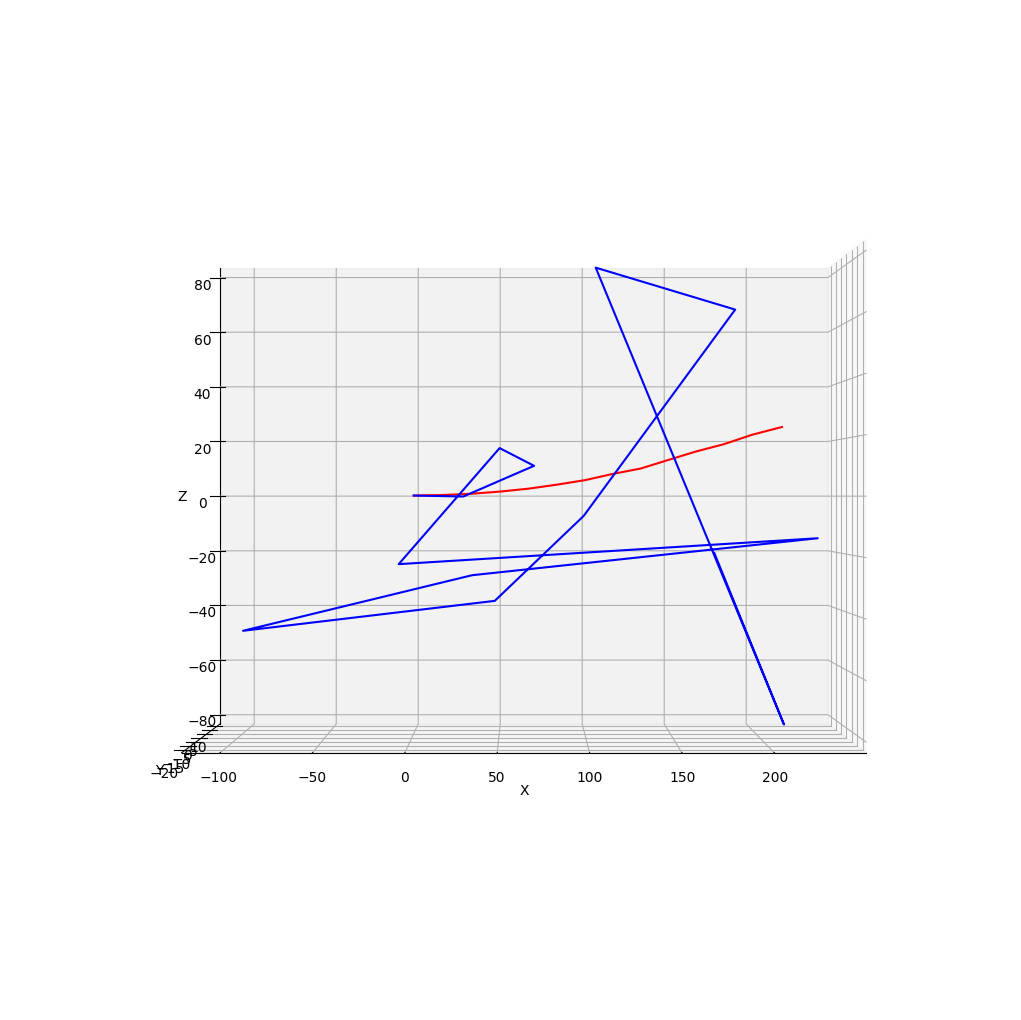

In [98]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [99]:
X,Y,Z

(array([  0.        ,  28.9950016 ,  70.39746629,  50.08231352,
        -11.37195471, 226.27667898,  36.1254292 , -97.26213269,
         47.43545323,  99.4854465 , 185.49718191, 106.41422024,
        216.30695298, 175.70480845]),
 array([ 0.00000000e+00, -1.60243863e-02,  1.07253859e+00,  2.92203068e+00,
         1.05932193e+01, -1.76367278e+01, -2.03195727e+01, -4.73387802e+00,
        -6.11809406e-01,  7.05998152e-01, -6.18351872e+00, -2.17031206e-01,
        -5.09106958e-01, -3.14486205e-01]),
 array([  0.21336082,  -0.12543481,  10.68835384,  17.03048337,
        -24.70949062, -13.91123283, -25.89172141, -46.52541065,
        -36.68489877,  -6.94823308,  64.15460841,  80.15940559,
        -80.03490664, -19.96621077]))

In [100]:
X0,Y0,Z0

(array([  0.        ,  16.03106594,  33.82724389,  50.72469755,
         67.3826449 ,  83.70647832, 100.2041929 , 116.09389083,
        132.89613825, 148.5581242 , 164.64357056, 181.5372078 ,
        198.01302769, 215.42335191]),
 array([ 0.00000000e+00, -3.12409611e-07,  1.60087438e-07, -3.93150913e-07,
        -6.38865458e-08,  1.33928552e-07, -3.17730155e-07,  2.95767677e-09,
         2.32092134e-07, -1.09273060e-06,  1.57437353e-06, -1.15215880e-06,
         2.25960321e-07, -4.11700967e-07]),
 array([ 0.21336082,  0.37944325,  0.85125302,  1.61520718,  2.6467297 ,
         4.03081109,  5.61988748,  7.76206097,  9.71997196, 12.63712127,
        15.60273056, 18.26112421, 21.5679122 , 24.28058907]))

In [101]:
us=fin.T

In [102]:
us.shape

(308, 12508)

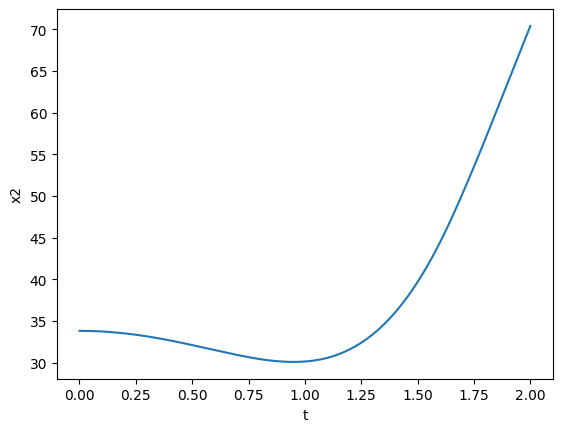

In [103]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

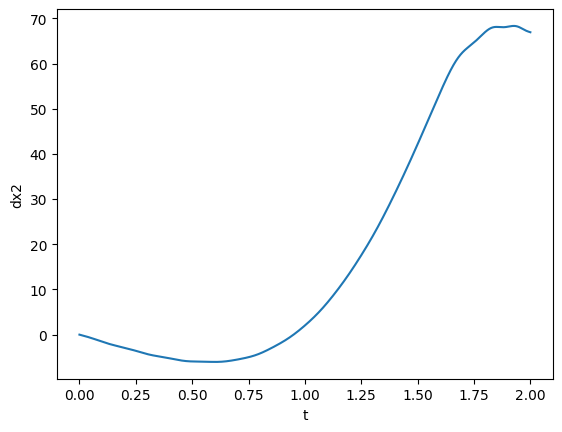

In [104]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

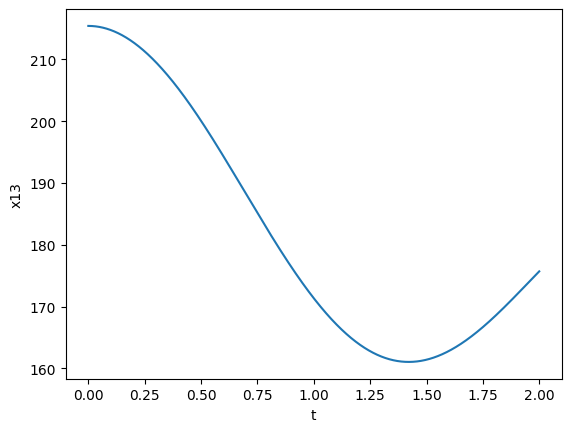

In [105]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

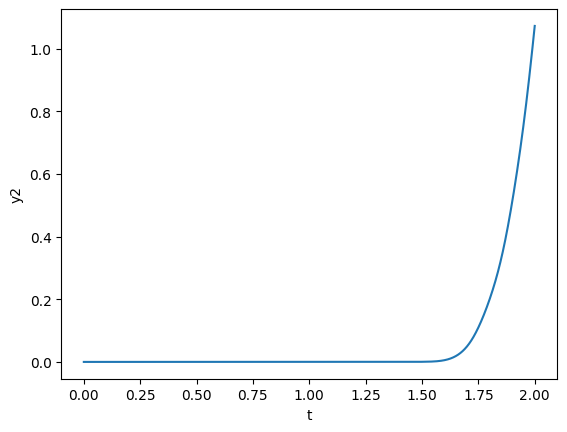

In [106]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

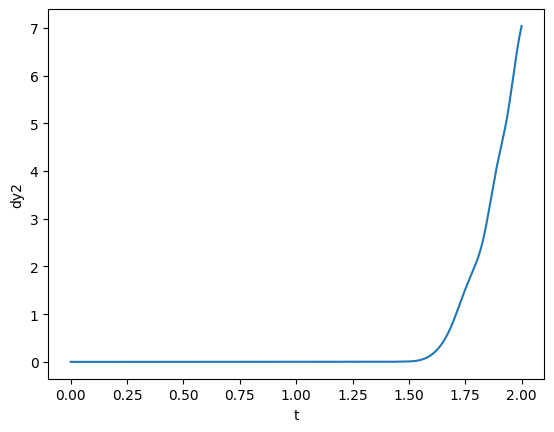

In [107]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

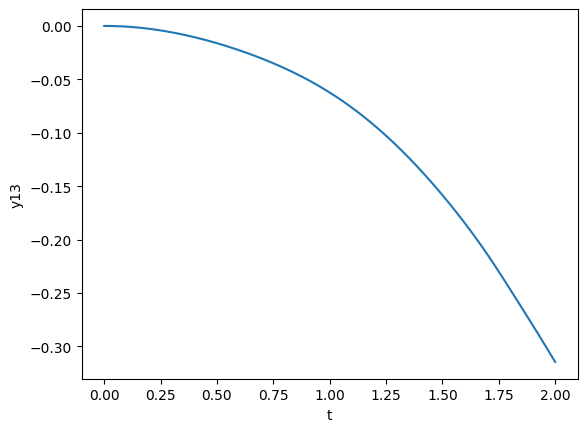

In [108]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

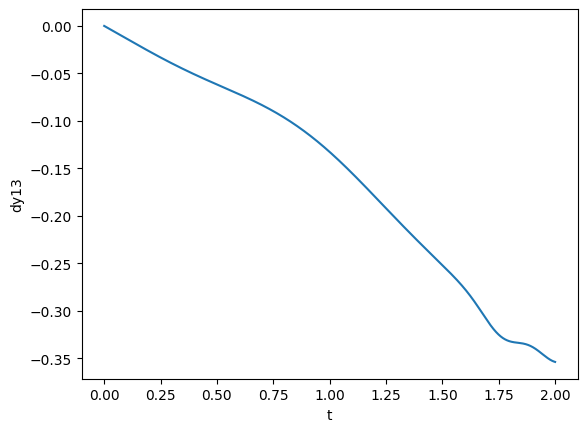

In [109]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

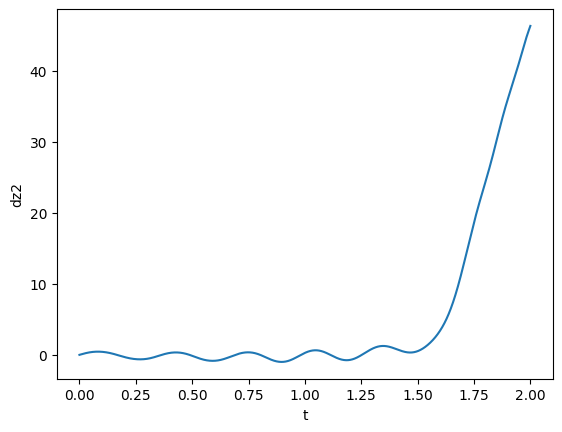

In [110]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

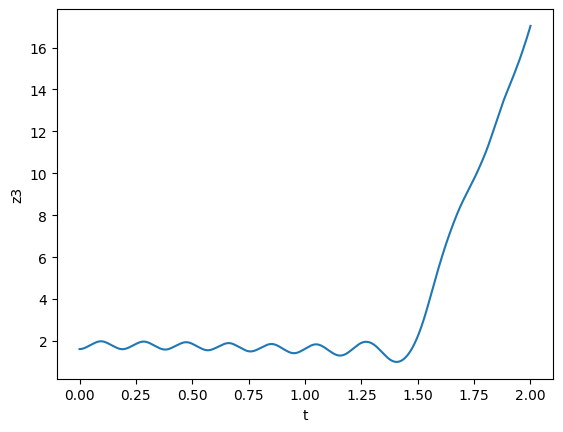

In [111]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

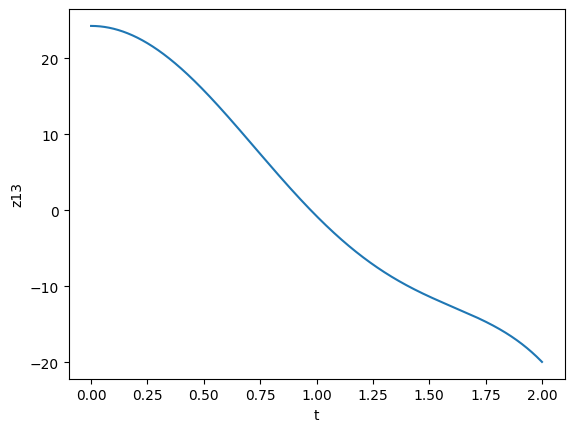

In [112]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

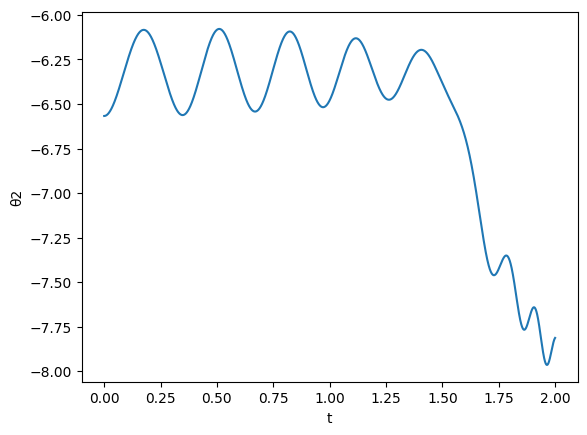

In [113]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

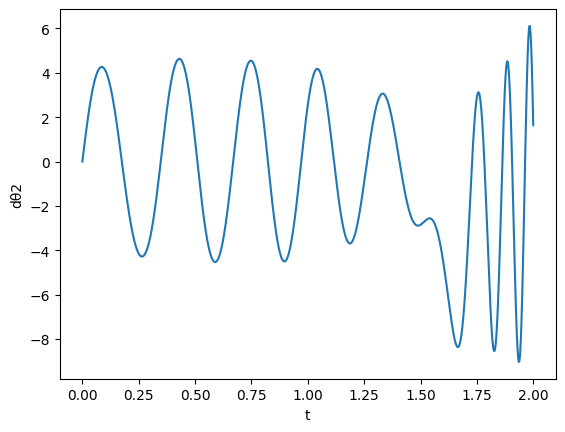

In [114]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

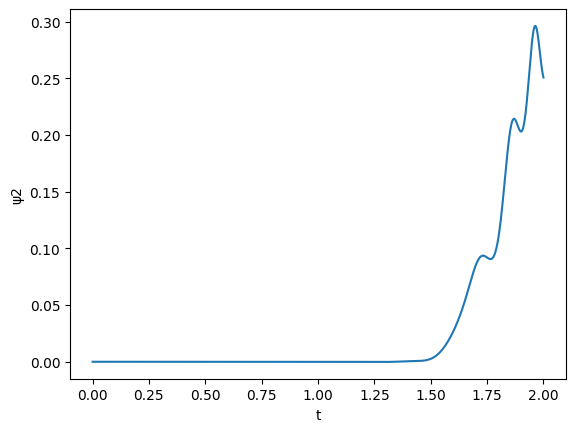

In [115]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

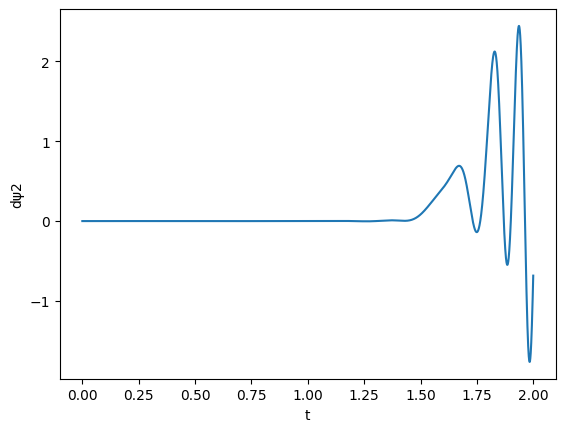

In [116]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

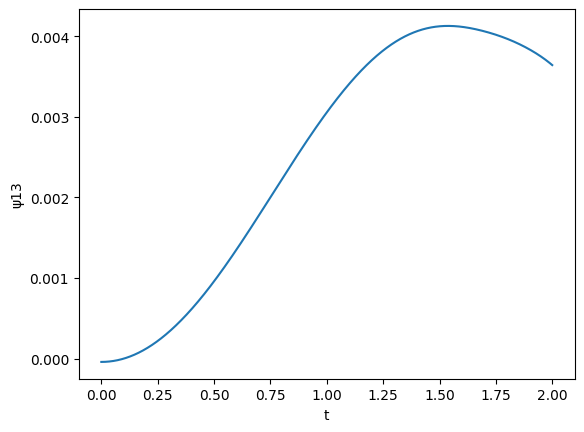

In [117]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [118]:
X010=us.T[:,0*N:1*N]

In [119]:
Y010=us.T[:,2*N:3*N]

In [120]:
Z010=us.T[:,4*N:5*N]

In [121]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 10                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()